In [34]:
%matplotlib ipympl

import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import axes
import matplotlib.colors
from matplotlib.colors import LogNorm
import random
import os
import cv2
from PIL import Image 


In [ ]:
#info you need to specify
main_dir = '/Users/labtest/Desktop/test_dlc/'
csv_openfield = main_dir + 'mouse_openfieldDLC_resnet50_mice_openfieldMay16shuffle1_2000.csv' #<- change path for the csv 
body_parts = ['tailset', 'nose', 'leftear','rightear'] #<- which body parts should be plottend on CONNECTED graph (fig 1)
scorer = 'DLC_resnet50_mice_openfieldMay16shuffle1_2000' #<- second column in csv 
file = pd.read_csv(csv_openfield, header=[0, 1, 2])
mp4_file = main_dir + 'mouse_openfieldDLC_resnet50_mice_openfieldMay16shuffle1_2000_filtered_labeled.mp4'
file.head()


Frame saved as frame105.png


scorer DLC_resnet50_mice_openfieldMay16shuffle1_2000              \
  bodyparts                                          nose               
     coords                                             x           y   
0         0                                   2680.141113  904.032043   
1         1                                   2685.573730  900.132324   
2         2                                   2687.833252  897.970825   
3         3                                   2686.255859  894.037781   
4         4                                   2685.550781  890.723022   

                                                                           \
                  leftear                            rightear               
  likelihood            x           y likelihood            x           y   
0   0.488586  2626.425293  875.240479   0.623971  2638.995361  928.946289   
1   0.414307  2632.785889  870.759460   0.754482  2641.682617  921.431641   
2   0.501130  2643.897217  918.957458   0.815771  2645.363770  919.059448   
3   0.331384  2643.974121  918.592896   0.829135  2645.237549  918.961426   
4   0.302112  2644.558594  916.566589   0.834749  2645.936279  917.343384   

                                                  
                  tailset                         
  likelihood            x           y likelihood  
0   0.676052  2445.670898  935.580750   0.844128  
1   0.744682  2444.102539  935.258362   0.827776  
2   0.835628  2442.159912  935.559326   0.755265  
3   0.845985  2442.918213  935.576416   0.699503  
4   0.848220  2441.107178  933.210083   0.772450

In [ ]:
def plot_background(mp4_file, main_dir):
    cap = cv2.VideoCapture(mp4_file)
    number = 105
    frame_number = number
    frame_name = 'frame'+ str(number)+ '.png'
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    if ret:
        path_to_save = os.path.join(main_dir, frame_name)
        cv2.imwrite(path_to_save, frame)
        print("Frame saved as frame"+str(number)+'.png')
    return frame_name
frame_name = plot_background(mp4_file, main_dir)
bg_img = Image.open(main_dir + frame_name)

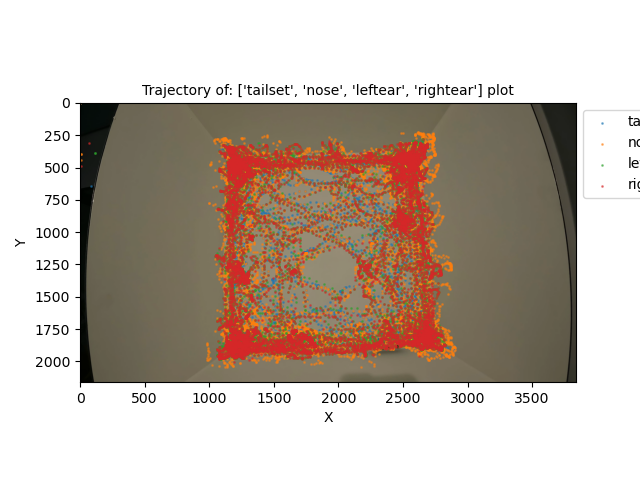

In [58]:
def all_body_parts_points_plot (file, body_parts):
    fig, ax = plt.subplots()
    ax.set_title ( "Trajectory of: " + str(body_parts) + ' plot', loc='center', fontsize = 'medium')
    ax.imshow(bg_img)
    for part in body_parts:
        x = file[( scorer, part, 'x')]
        y = file[( scorer, part, 'y')]
        ax.scatter(x, y, s=1, alpha=0.5, label = part)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.show
all_body_parts_points_plot(file, body_parts)    

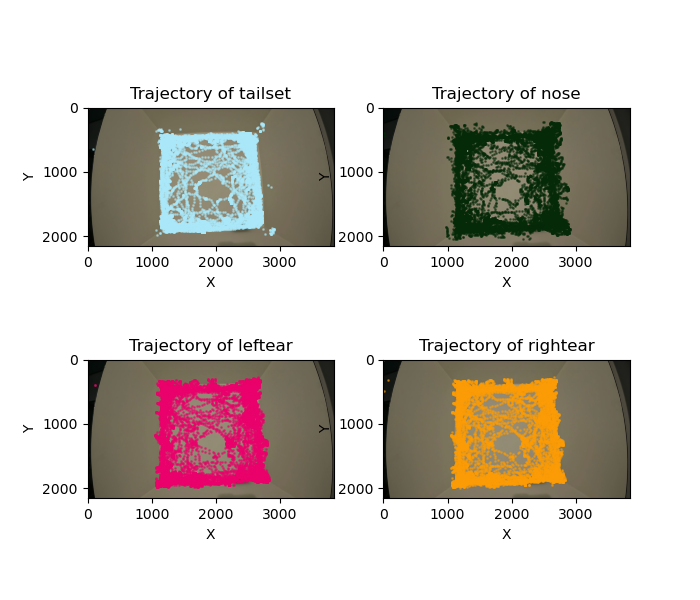

In [59]:
def plots_of_each_bodypart_separate (file, body_parts):
    fig, axs = plt.subplots(2, 2, figsize=(7,6))
    axs = axs.flatten()
    for ax, part in zip(axs, body_parts):
        x = file[(scorer, part, 'x')]
        y = file[(scorer, part, 'y')]
        color = (random.uniform(0, 1), random.uniform(0, 1), random.uniform(0, 1))
        ax.imshow(bg_img)
        ax.scatter(x, y, s=1, alpha=0.5, label=part, color=color)
        ax.set_title(f"Trajectory of {part}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
    plt.show()
plots_of_each_bodypart_separate(file, body_parts)

In [60]:
plt.close('all')

In [61]:
def coords_to_centroid(file, body_parts, scorer):
    coords_df = file[scorer].loc[:, (body_parts, ['x', 'y'])]
    x_cols = [col for col in coords_df.columns if col[1] == 'x']
    y_cols = [col for col in coords_df.columns if col[1] == 'y']
    coords_df['centroid_x'] = coords_df[x_cols].mean(axis=1)
    coords_df['centroid_y'] = coords_df[y_cols].mean(axis=1)
    x = coords_df['centroid_x']
    y = coords_df['centroid_y']
    return x, y
x, y = coords_to_centroid(file, body_parts, scorer)

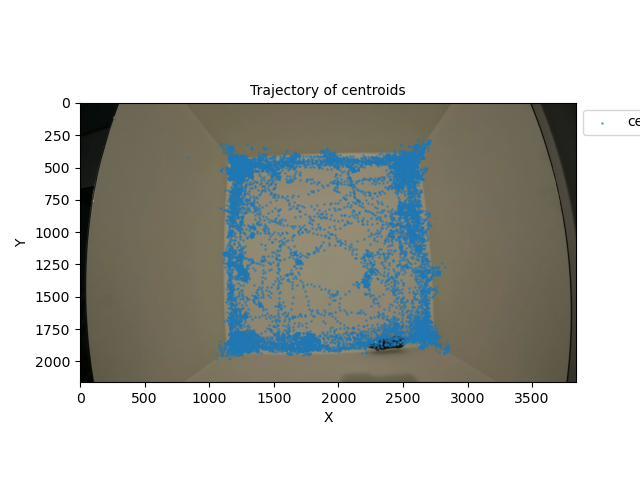

In [62]:
def centroid_points_plot (file, x, y):
    fig, ax = plt.subplots()
    ax.set_title ( "Trajectory of centroids",  loc='center', fontsize = 'medium')
    ax.imshow(bg_img)
    x = x
    y = y
    ax.scatter(x, y, s=1, alpha=0.5, label='centroid')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.show
centroid_points_plot(file, x, y) 

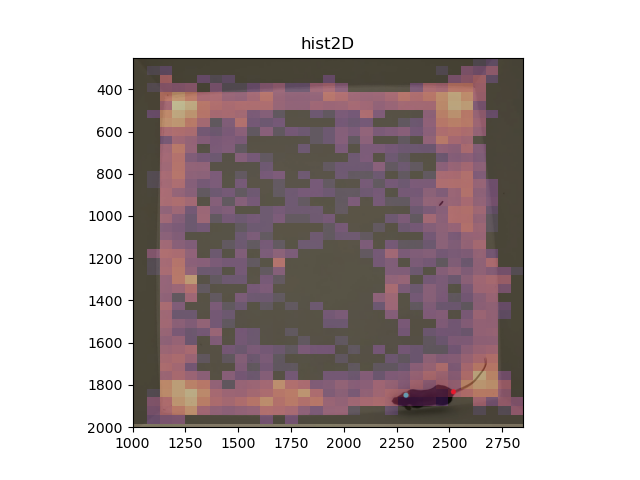

In [64]:
def hist2d_centroid_plot (x, y, bins = 48):
    fig, ax = plt.subplots()
    ax.imshow(bg_img)
    x = x
    y = y
    my_cmap = matplotlib.colormaps.get_cmap('magma').copy()
    my_cmap.set_bad((0,0,0))
    hist = ax.hist2d(
        x, 
        y, 
        density=True, 
        bins = bins,  #<- calculated using Rice criterion
        norm = matplotlib.colors.LogNorm(),
        cmap=my_cmap,
        alpha = 0.4
    )
    ax.set_title('hist2D', loc = 'center')
    ax.set_xlim(1000, None)
    ax.set_ylim(250, 2000)
    plt.gca().invert_yaxis()
    plt.show
hist2d_centroid_plot(x, y)

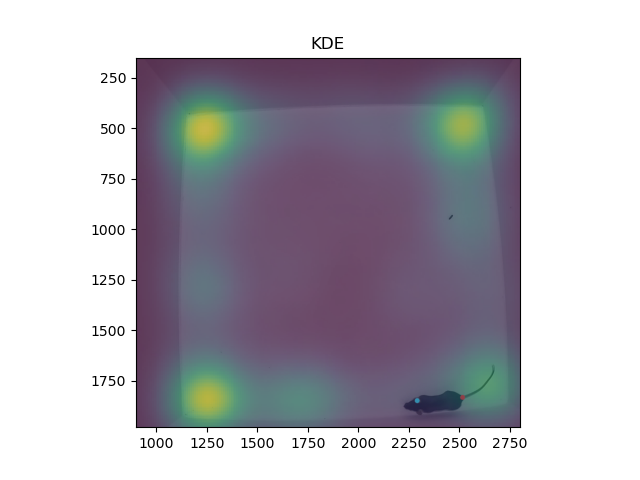

In [ ]:
def kde_plot_centroids( x, y, nbins = 300):
    nbins = nbins
    k = gaussian_kde([x,y])
    xi, yi = np.mgrid[x.min():x.max():nbins*1j,y.min():y.max():nbins*1j]
    zi = k(np.vstack([xi.flatten(),yi.flatten()])).reshape(xi.shape)
    fig, ax = plt.subplots()
    ax.imshow(bg_img)
    ax.pcolormesh(xi, yi, zi, alpha=0.5)
    ax.set_xlim(900, 2800)
    ax.set_ylim(150, 1980)
    ax.set_title('KDE')
    plt.gca().invert_yaxis()
    plt.show()
kde_plot_centroids(x, y)  